# Notebook prêt à compléter
Ce notebook sert de support au projet TensorFlow texte + tabulaire.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Chargement des données 

In [24]:
df = pd.read_csv(r"C:\Users\yamba\Documents\projetDL\customer-support-priority-classification-and-routing\data\raw\customer_support_tickets.csv")

In [25]:
print("--- Aperçu des données ---")
print(f"Le dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")
print(df.info())
print("\n--- Échantillon ---")
print(df.head(3))

--- Aperçu des données ---
Le dataset contient 8469 lignes et 17 colonnes.
<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12

Vérification des valeurs manquantes et doublons

In [26]:
print("\n--- Nettoyage de base ---")
print("Valeurs manquantes par colonne :\n", df.isnull().sum())
print(f"Nombre de lignes doublons : {df.duplicated().sum()}")


--- Nettoyage de base ---
Valeurs manquantes par colonne :
 Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64
Nombre de lignes doublons : 0


Distribution de la variable cible

C:\Users\yamba\AppData\Local\Temp\ipykernel_3528\30809695.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Ticket Type', data=df, order=df['Ticket Type'].value_counts().index, palette='viridis')


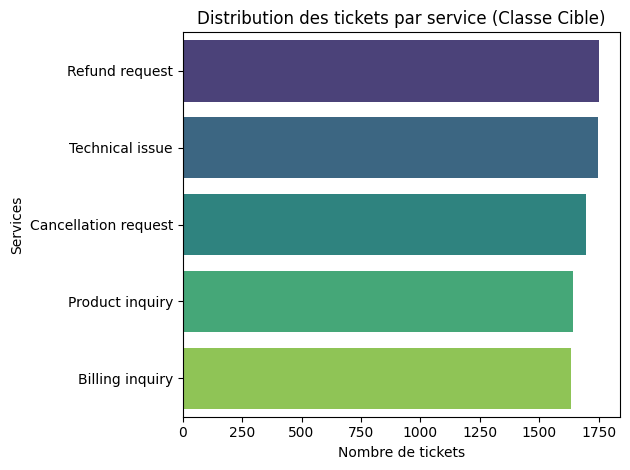

In [27]:
plt.figure()
sns.countplot(y='Ticket Type', data=df, order=df['Ticket Type'].value_counts().index, palette='viridis')
plt.title("Distribution des tickets par service (Classe Cible)")
plt.xlabel("Nombre de tickets")
plt.ylabel("Services")
plt.tight_layout()
plt.show()

Analyse de la longueur du texte

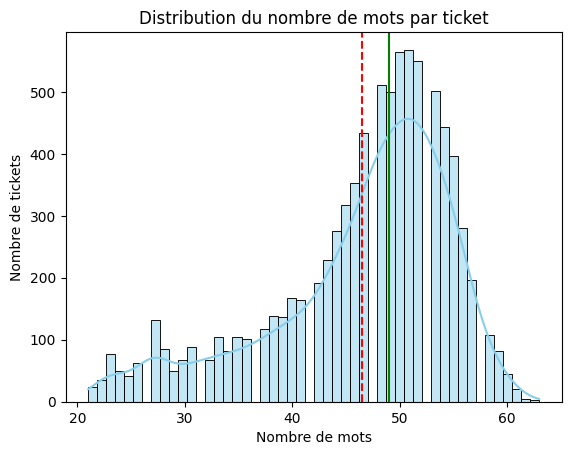

In [28]:
df['word_count'] = df['Ticket Description'].apply(lambda x: len(str(x).split()))

plt.figure()
sns.histplot(df['word_count'], bins=50, kde=True, color='skyblue')
plt.title("Distribution du nombre de mots par ticket")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre de tickets")
plt.axvline(x=df['word_count'].mean(), color='red', linestyle='--', label=f"Moyenne: {df['word_count'].mean():.1f}")
plt.axvline(x=df['word_count'].median(), color='green', linestyle='-', label=f"Médiane: {df['word_count'].median():.1f}")

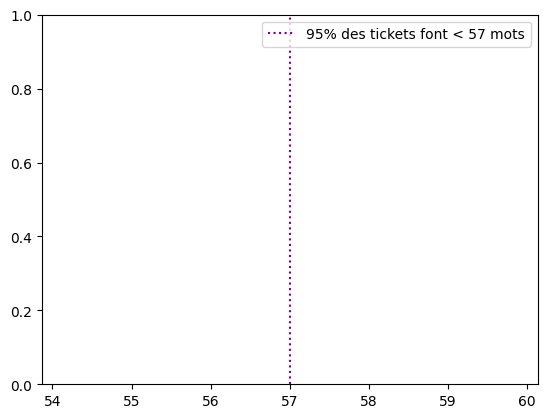

In [29]:
# Calcul du 95ème percentile
percentile_95 = np.percentile(df['word_count'], 95)
plt.axvline(x=percentile_95, color='purple', linestyle=':', label=f"95% des tickets font < {int(percentile_95)} mots")

plt.legend()
plt.show()

Longueur du texte selon la catégorie

C:\Users\yamba\AppData\Local\Temp\ipykernel_3528\3877929599.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='word_count', y='Ticket Type', data=df, palette='vlag')


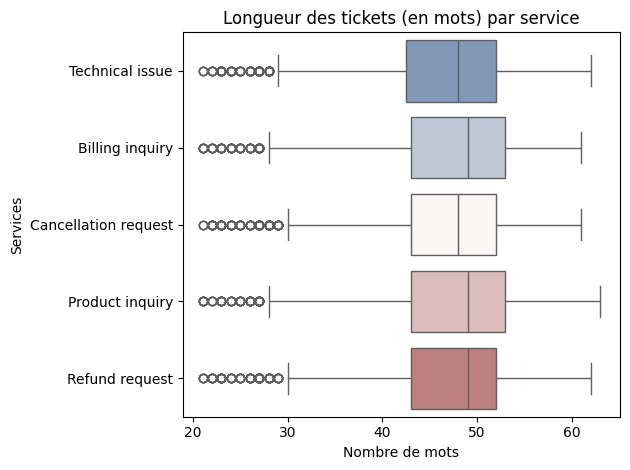

In [30]:
plt.figure()
sns.boxplot(x='word_count', y='Ticket Type', data=df, palette='vlag')
plt.title("Longueur des tickets (en mots) par service")
plt.xlabel("Nombre de mots")
plt.ylabel("Services")
plt.tight_layout()
plt.show()